In [5]:
import sys

%pip install torch torchvision matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from sklearn.metrics import confusion_matrix, classification_report

In [7]:
train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 9.91M/9.91M [00:07<00:00, 1.34MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 106kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 748kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.68MB/s]


In [8]:
print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

Training samples: 60000
Testing samples: 10000


In [9]:
image, label = train_data[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([1, 28, 28])
Label: 5


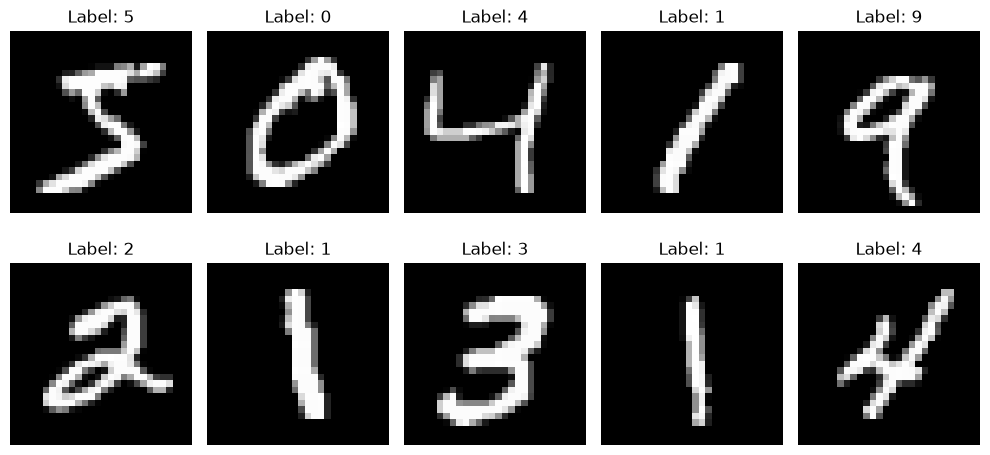

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_data[i]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
batch_size = 64

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

In [12]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([64, 1, 28, 28])
Labels: torch.Size([64])


In [13]:
# Create CNN

In [14]:
def evaluate_model(model,loader):
    model.eval()
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_predictions.extend(
                predicted.cpu().numpy()
            )

            alllabels.extend(
                labels.cpu().numpy()
            )

    accuracy = 100 * correct/total

    return accuracy, all_labels, all_predictions
    

SyntaxError: invalid syntax (4115225346.py, line 21)